In [31]:
import glob
import subprocess
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from concurrent.futures import ProcessPoolExecutor
import os, shutil
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings("ignore")
from xspec import Spectrum, Model, Fit, Xset, PlotManager, Plot, AllModels, AllData, Chain, AllChains, FakeitSettings
# import acx2_xspec

In [32]:
plt.style.use("default")
plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)
plt.rc('axes', linewidth=1.15)

size = 11
plt.rc("mathtext", fontset="dejavuserif")
plt.rc('font', family='DejaVu Serif', size=size)

In [ ]:
modelname = f'BKG_apec_tbabs_apec_apec_po'

Dir = '../Data/Spectra/'
bkgfile=f'Background_820_SourceSpec_00001_corr.fits'

rmf = f'background_820_RMF_00001.fits'
arf = f'background_820_ARF_00001_corr.fits'

output_dir = os.path.join(Dir, "Fitting_Results", modelname)
os.makedirs(output_dir, exist_ok=True)
# plots_dir = os.path.join(output_dir, "Plots")
# mcmc_dir = os.path.join(output_dir, "MCMC_Results")
# os.makedirs(plots_dir, exist_ok=True)
# os.makedirs(mcmc_dir, exist_ok=True)

In [34]:
Xset.xsect = 'vern'
Xset.abund = 'wilm'
Fit.statMethod = 'cstat'
Xset.chatter = 1
Xset.allowPrompting = False

In [35]:
AllData.clear()

pwd = os.getcwd()
os.chdir(Dir)

sp_bkg = Spectrum(bkgfile)
sp_bkg.multiresponse[0] = rmf
sp_bkg.multiresponse[0].arf = arf
sp_bkg.multiresponse[1] = rmf
os.chdir(pwd)  # switch the current dirctory back
# sp_bkg.multiresponse[1].arf = arf

In [36]:
AllData.ignore("**-0.2,8.0-**")

In [37]:
Xset.chatter = 10
AllData.show()
Xset.chatter = 1


1 file 1 spectrum 
Spectrum 1  Spectral Data File: Background_820_SourceSpec_00001_corr.fits
Net count rate (cts/s) for Spectrum:1  1.817e+01 +/- 2.138e-01
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  21-796
  Telescope: eROSITA Instrument: MERGED  Channel Type: PI
  Exposure Time: 397.5 sec
 Using fit statistic: cstat
 Using Response (RMF) File            background_820_RMF_00001.fits for Source 1
 Using Auxiliary Response (ARF) File  background_820_ARF_00001_corr.fits
 Using Response (RMF) File            background_820_RMF_00001.fits for Source 2



In [38]:
AllModels.clear()
Xset.chatter = 1
m_bkg = Model("apec+TBabs(apec+apec+powerlaw)", "bkg", 1)  # define model for src2 and name it "bkg"

Xset.restore(f"{Dir}/TM8_FWC_c010_mod_customized_bkg.dat")  # load fwc model from the file
m_fwc = AllModels(1, "fwc")  # point the "fwc" model from data group 1 to the variable m_fwc

# to set all parameters of fwc frozon, except the constant.
for _name in m_fwc.componentNames:
    if _name != "constant":
        _comp = m_fwc.__getattribute__(_name)
        for _pname in _comp.parameterNames:
            _par = _comp.__getattribute__(_pname)
            _par.frozen = True


***Warning: The file sent to Xset.restore(): ../Data/Spectra//TM8_FWC_c010_mod_customized_bkg.dat
    is not detected to be a file generated from Xset.save().
    Xset.restore() usage is only intended for Xset.save() output.
    General XSPEC/Tcl scripts may not fully execute in PyXspec.




In [39]:
m_bkg.TBabs.nH = 0.25
# m_bkg.constant.factor= 1, -1
m_bkg.powerlaw.PhoIndex = 1.46, -1
# m_bkg.powerlaw.norm = 1e-1
m_bkg.apec.kT = 0.1
# m_bkg.apec.norm = 1.71999e-06
m_bkg.apec_3.kT = 0.25, -1
# m_bkg.apec.Abundanc.frozen = False
# m_bkg.apec_3.norm = 6.74433e-05
m_bkg.apec_4.kT = 0.6
# m_bkg.apec_4.norm = 3.03316e-07

In [40]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model bkg:apec<1> + TBabs<2>(apec<3> + apec<4> + powerlaw<5>) Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   apec       kT         keV      0.100000     +/-  0.0          
   2    1   apec       Abundanc            1.00000      frozen
   3    1   apec       Redshift            0.0          frozen
   4    1   apec       norm                1.00000      +/-  0.0          
   5    2   TBabs      nH         10^22    0.250000     +/-  0.0          
   6    3   apec       kT         keV      0.250000     frozen
   7    3   apec       Abundanc            1.00000      frozen
   8    3   apec       Redshift            0.0          frozen
   9    3   apec       norm                1.00000      +/-  0.0          
  10    4   apec       kT         keV      0.600000     +/-  0.0          
  11    4   apec       Abundanc            1.00000      frozen
  12    4   apec       Redshift            0.0          frozen
  13    4   ape

In [41]:
Xset.chatter = 10
Fit.query = "yes"
Fit.nIterations = 1000
Fit.perform()
Xset.chatter = 1

                                   Parameters
C-Statistic  |beta|/N    Lvl      bkg:1:kT    bkg:4:norm      bkg:5:nH    bkg:9:norm     bkg:10:kT   bkg:13:norm   bkg:15:norm  fwc:1:factor
851.448      9264.52      -3      0.129600    0.00244009      0.351014    0.00390365      0.851655    0.00234624     0.0109016       1.13151
836.46       1240.51      -4      0.143619    0.00204163      0.400201    0.00390337      0.777758    0.00258531     0.0118997       1.17218
833.795      310.872      -5      0.160633    0.00200310      0.449887    0.00446932      0.757924    0.00335418     0.0121867       1.17189
830.777      247.132      -6      0.190816    0.00200648      0.502434    0.00225995      0.713597    0.00490397     0.0123613       1.17059
828.923      568.289      -1      0.197070    0.00217993      0.510034   0.000611483      0.730863    0.00517859     0.0124080       1.16845
828.813      155.431       0      0.197628    0.00219942      0.510749   0.000445169      0.733135    0.0052

In [42]:
stat = Fit.statistic
dof = Fit.dof
stat/dof

1.0785589943699645

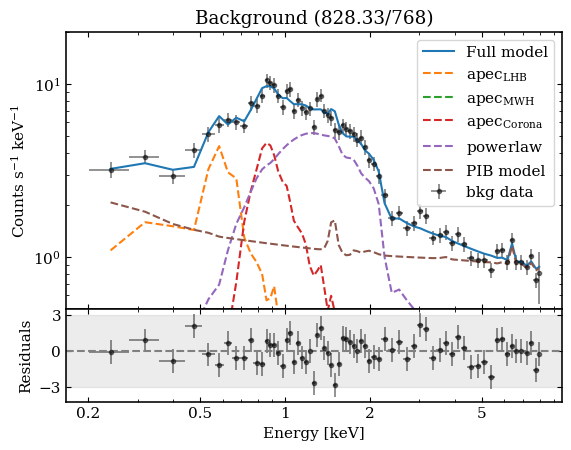

In [ ]:
Plot.device = "/null"
Plot.add = True
Plot.xAxis = "keV"
Plot.setRebin(minSig=10, maxBins=30)
Plot('ldata delchi')
total_model = Plot.model(1)
bkg_data = Plot.y(1)
bkg_data_err = Plot.yErr(1)
eng_bkg= Plot.x(1)
eng_bkg_err = Plot.xErr(1)
res_bkg = Plot.y(1,2)
res_bkg_err = Plot.yErr(1,2)
Pib_model = np.zeros(len(Plot.model(1)))
for i in range(5, Plot.nAddComps()+1):
    Pib_model += np.array(Plot.addComp(i, 1))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

# Plot the data and models
ax1.errorbar(eng_bkg, bkg_data, xerr=eng_bkg_err, yerr=bkg_data_err, fmt='.', color="black", label="bkg data", alpha=0.5, lw=1.2)
ax1.plot(eng_bkg, total_model, label="Full model")
ax1.plot(eng_bkg, Plot.addComp(1, 1), label=r"$\mathrm{apec_{LHB}}$", linestyle="--")
ax1.plot(eng_bkg, Plot.addComp(2, 1), label=r"$\mathrm{apec_{MWH}}$", linestyle="--")
ax1.plot(eng_bkg, Plot.addComp(3, 1), label=r"$\mathrm{apec_{Corona}}$", linestyle="--")
ax1.plot(eng_bkg, Plot.addComp(4, 1), label=r"$\mathrm{powerlaw}$", linestyle="--")
# ax1.plot(eng_bkg, Plot.addComp(3, 1), label=r"$\mathrm{powerlaw}$", linestyle="--")
ax1.plot(eng_bkg, Pib_model, label="PIB model", linestyle="--")
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_ylabel(r"$\mathrm{Counts\ s^{-1}\ keV^{-1}}$")
ax1.set_ylim(0.5, 2e1)
ax1.legend(loc="upper right")

# Plot the residuals
residuals = np.array(bkg_data) - np.array(total_model)
ax2.errorbar(eng_bkg, res_bkg, xerr=eng_bkg_err, yerr=res_bkg_err, fmt='.', color="black", label="residuals", alpha=0.5, lw=1.2)
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xscale("log")
ax2.set_xlabel("Energy [keV]")
ax2.set_ylabel("Residuals")
ax2.set_xticks([0.2, 0.5, 1, 2, 5])
ax2.set_xticklabels(['0.2', '0.5', '1', '2', '5'])
# ax2.set_ylim(-5, 5)
ax2.set_yticks([-3, 0, 3])
ax2.axhspan(-3, 3, color='gray', alpha=0.15)
ax1.set_title(f'Background ({stat:.2f}/{dof})')
fig.savefig(f"{output_dir}/PySpec_fitting_grp.png", dpi=300, bbox_inches="tight")

In [44]:
if os.path.exists(f'{output_dir}/bkg_xspec_model.xcm'):
    os.remove(f'{output_dir}/bkg_xspec_model.xcm')
Xset.save(f'{output_dir}/bkg_xspec_model.xcm')